In [32]:
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [33]:
#lectura csv final
df_final = pd.read_csv('files/hr_final.csv', index_col = 0)
df_final.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,41,True,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,0,8,0,1,6,4,0,5
2,49,False,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,1,10,3,3,10,7,1,7
4,37,True,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,True,15,3,2,0,7,3,3,0,0,0,0
5,33,False,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,True,11,3,3,0,8,3,3,8,7,3,0
7,27,False,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,False,12,3,4,1,6,3,3,2,2,2,2


In [34]:
variables_categoricas = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',  'MaritalStatus', 'OverTime']

In [35]:
variables_encuesta = ['EnvironmentSatisfaction', 'JobInvolvement','JobSatisfaction','RelationshipSatisfaction','WorkLifeBalance']

In [51]:
variables_salario = ['DailyRate','HourlyRate', 'MonthlyRate','MonthlyIncome','PercentSalaryHike']
variables_tiempo = [ 'TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
variables_numericas1 = ['DistanceFromHome','JobLevel','PerformanceRating','StockOptionLevel','TrainingTimesLastYear']
variables_numericas2= ['Age', 'Education','NumCompaniesWorked']

In [37]:
# conversión de Attrition en numérica para los gráficos
df_final['AttritioNum'] = df_final['Attrition'].astype(int)

- Correlación de attrition (abandono de la empresa) con las variables categóricas

In [44]:
def crear_graficos_barras(df, variables):
    
    for col in variables:

        # --- Barplot: tasa de attrition por categoría ---
        plt.figure(figsize=(8, 5))
        tasa = df.groupby(col)['AttritioNum'].mean().sort_values(ascending=False)
        sns.barplot(x=tasa.index, y=tasa.values, palette='mako')
        plt.title(f'Tasa de Abandono por {col}')
        plt.ylabel('Proporción que se va')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

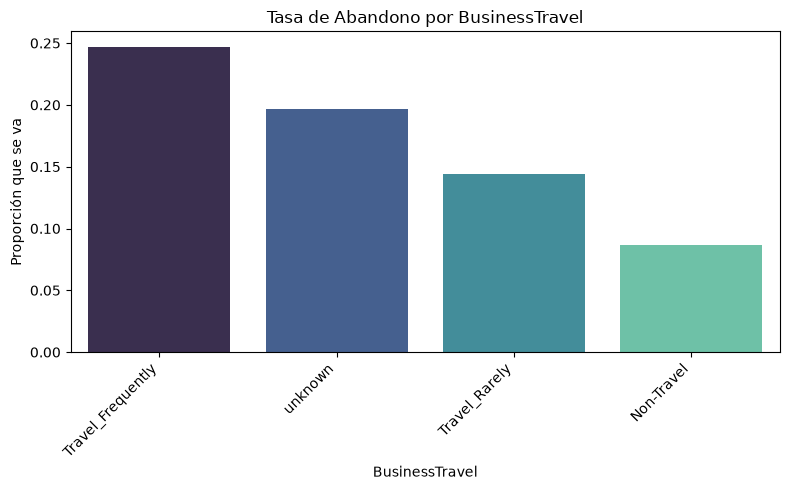

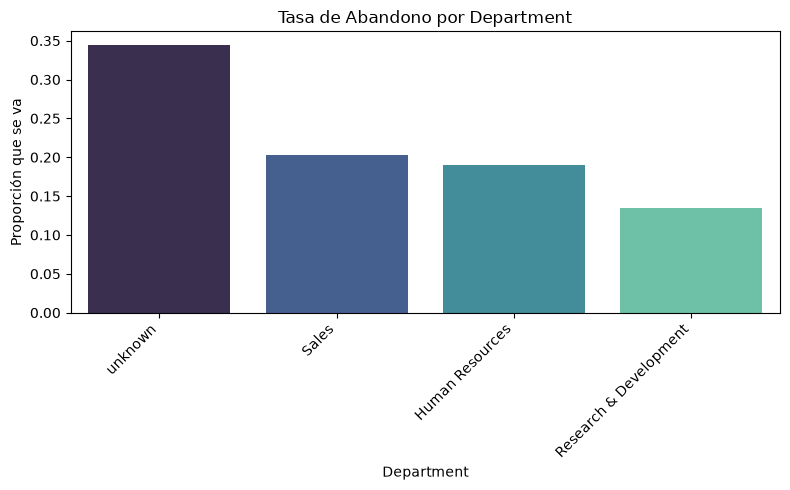

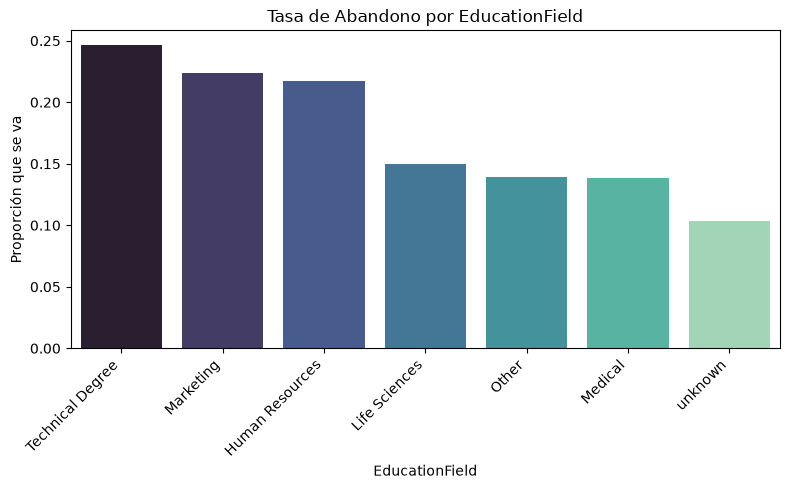

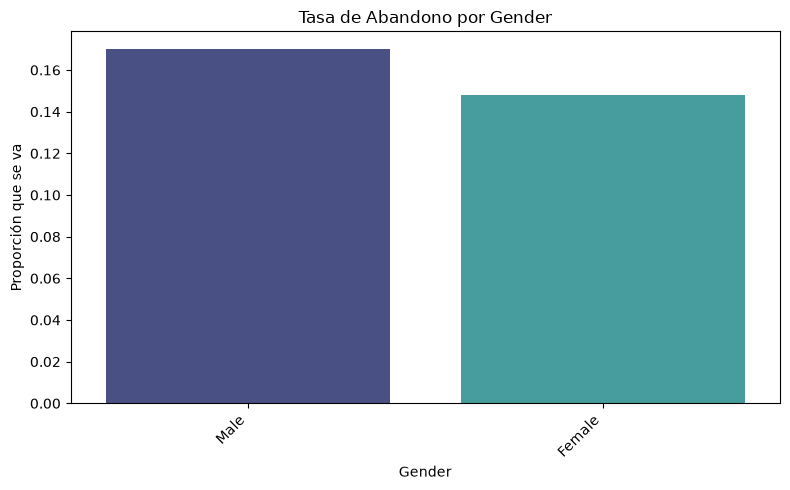

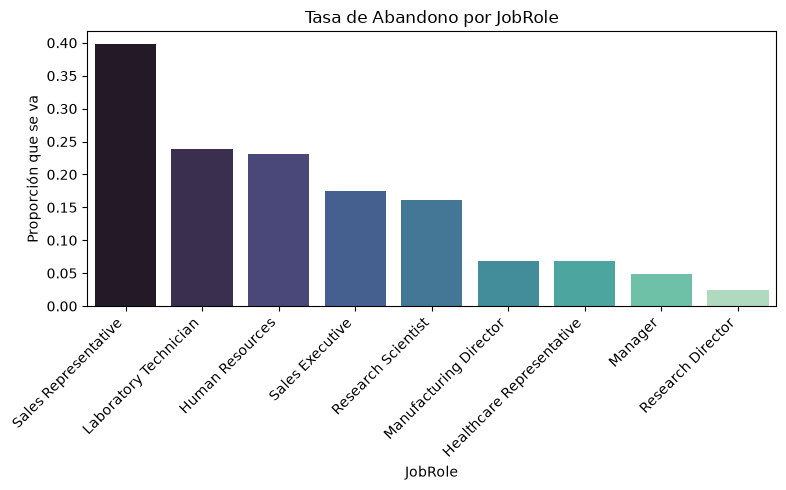

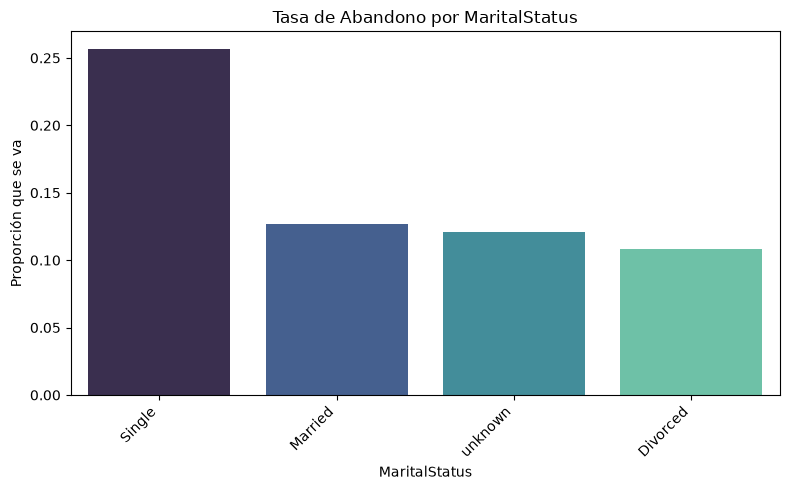

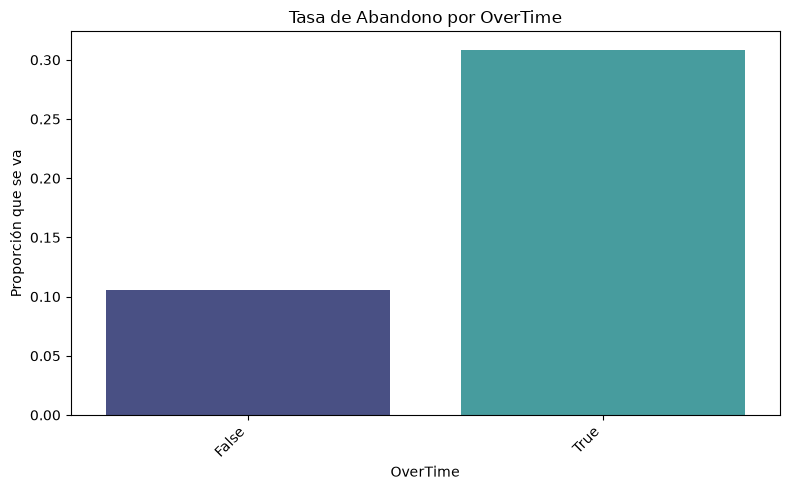

In [45]:
crear_graficos_barras(df_final, variables_categoricas)


- Correlación de attrition con las variables encuesta

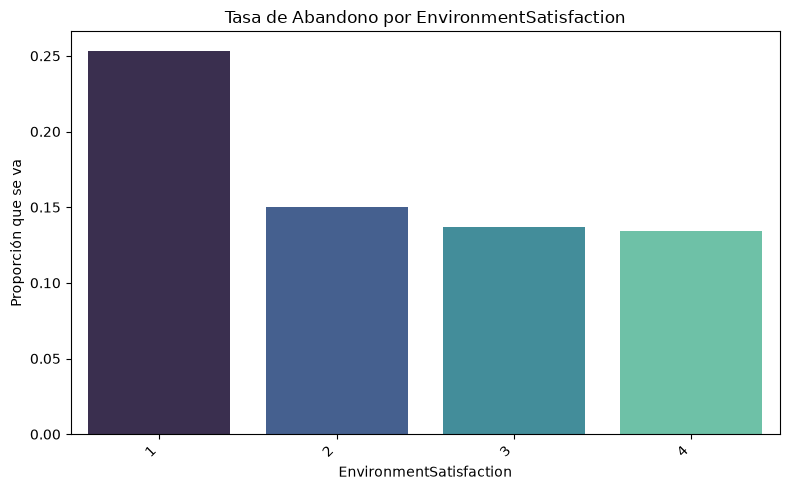

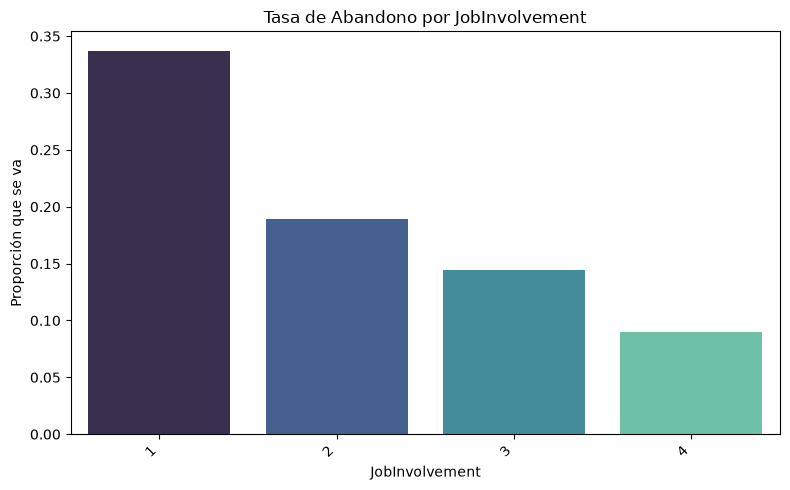

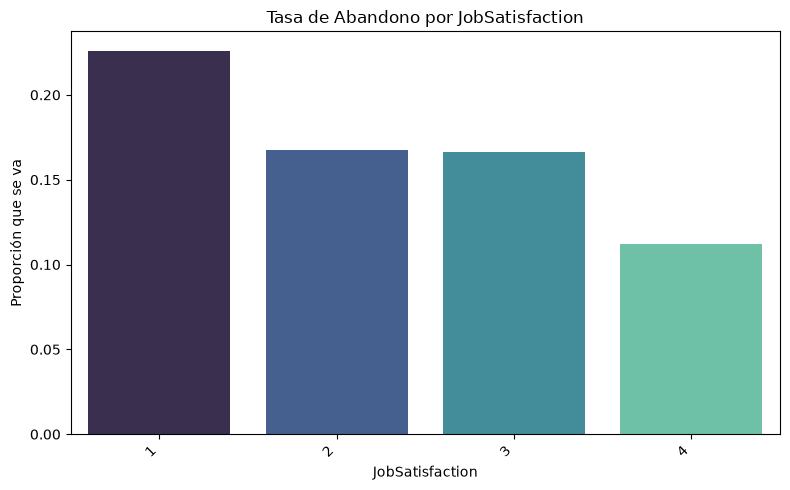

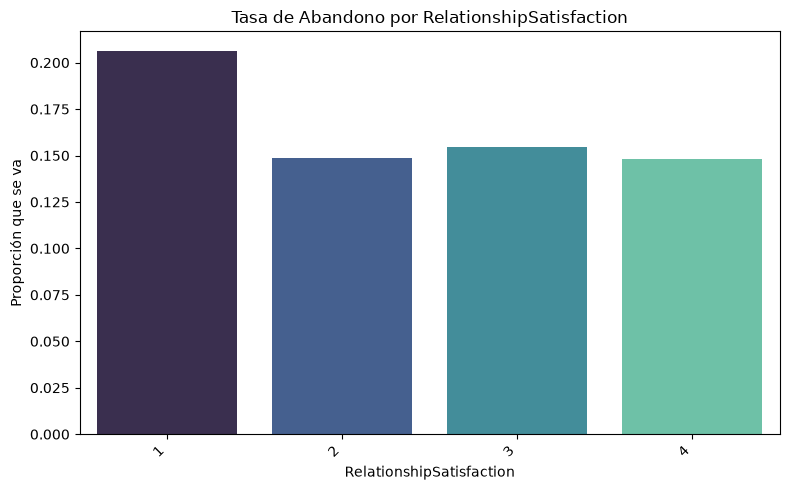

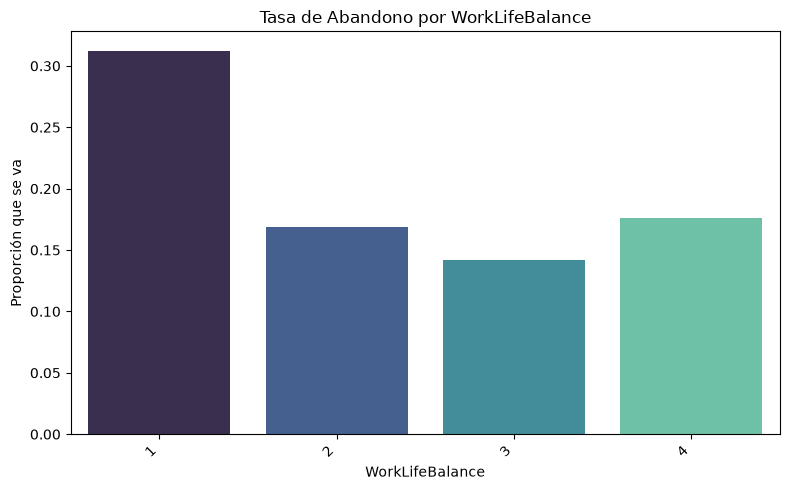

In [46]:
crear_graficos_barras(df_final, variables_encuesta)

- Matriz de correlación con las variables numericas más interesantes

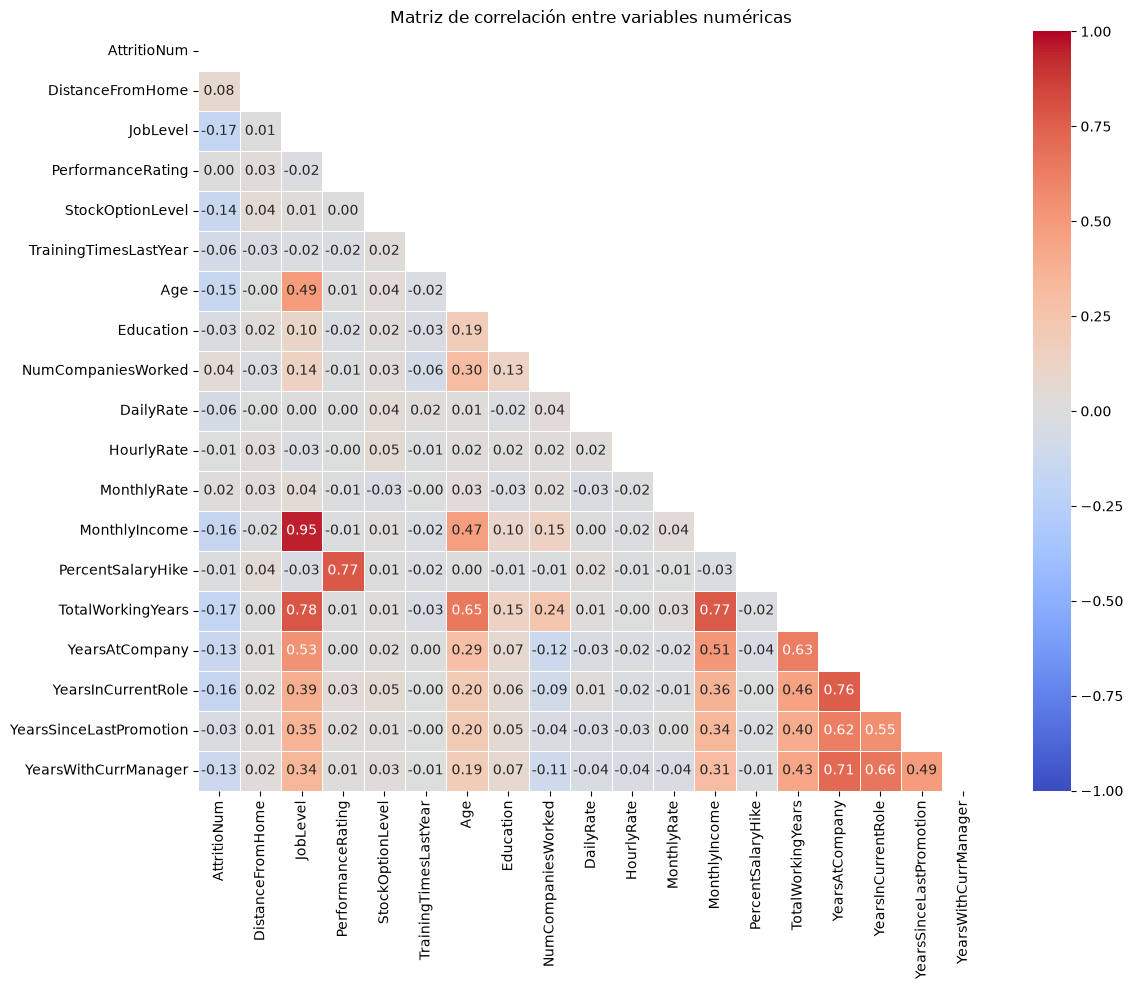

In [42]:
cols_heatmap = ['AttritioNum'] + list(dict.fromkeys(variables_numericas1 + variables_numericas2 + variables_salario + variables_tiempo)) 
correlacion_matrix = df_final[cols_heatmap].corr()
masc = np.triu(np.ones_like(correlacion_matrix, dtype=bool)) 
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

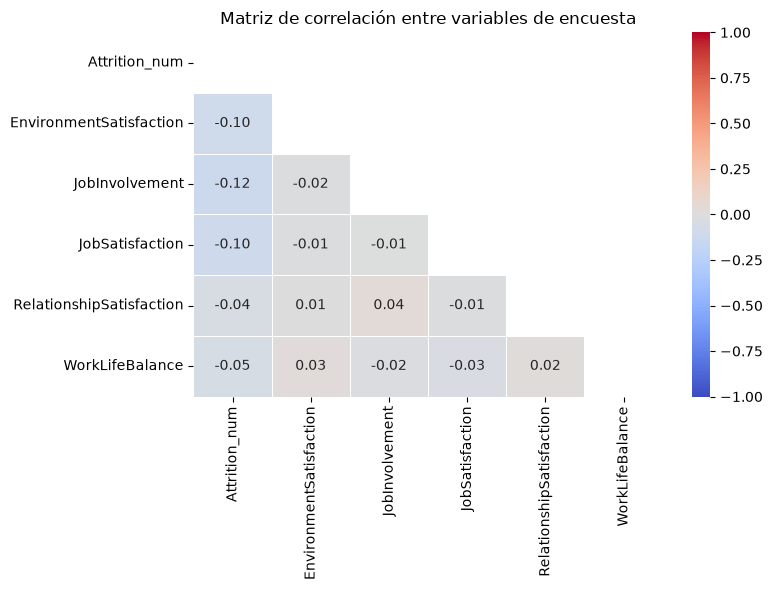

In [ ]:
cols_heatmap = ['AttritioNum'] + variables_encuesta
correlacion_matrix2 = df_final[cols_heatmap].corr(method='spearman')
masc = np.triu(np.ones_like(correlacion_matrix2, dtype=bool)) 
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_matrix2, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables de encuesta')
plt.tight_layout()
plt.show()

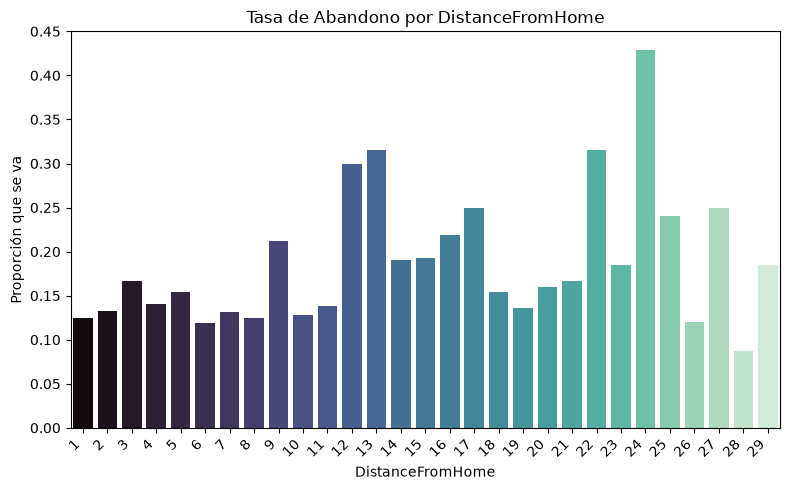

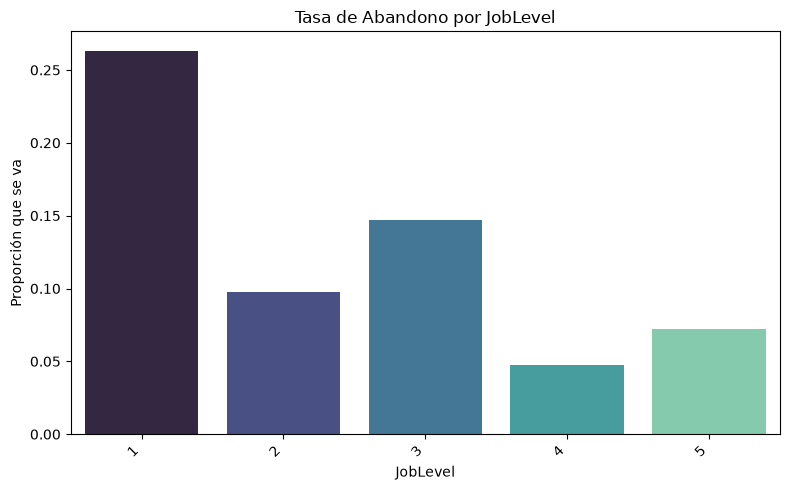

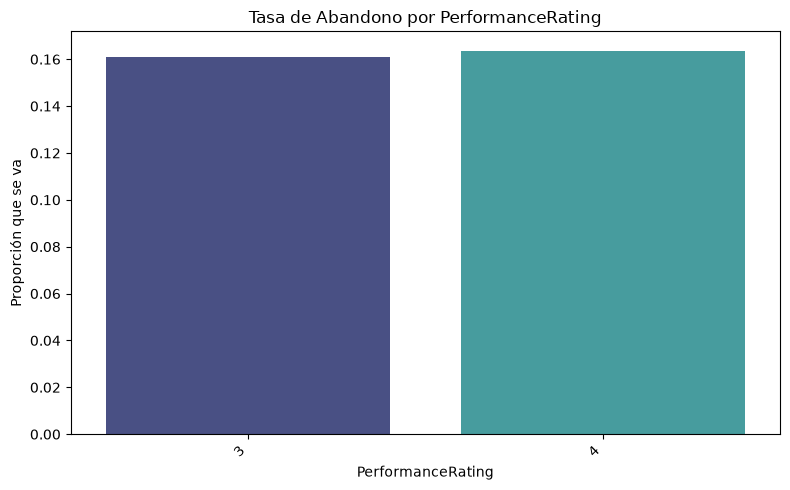

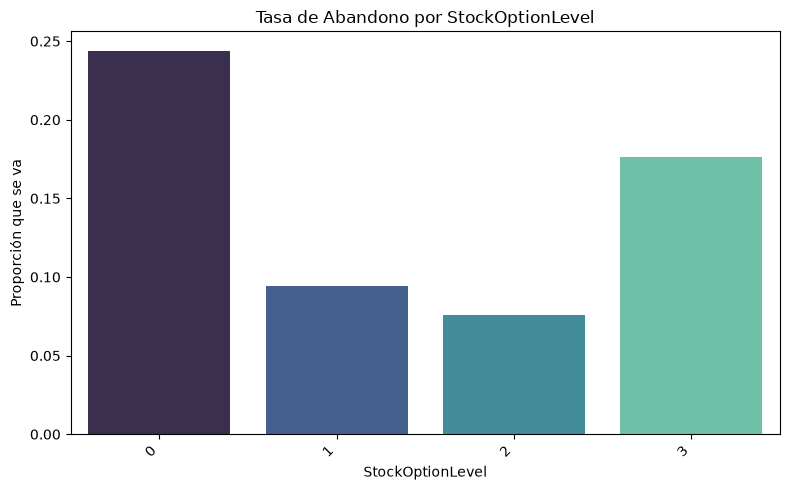

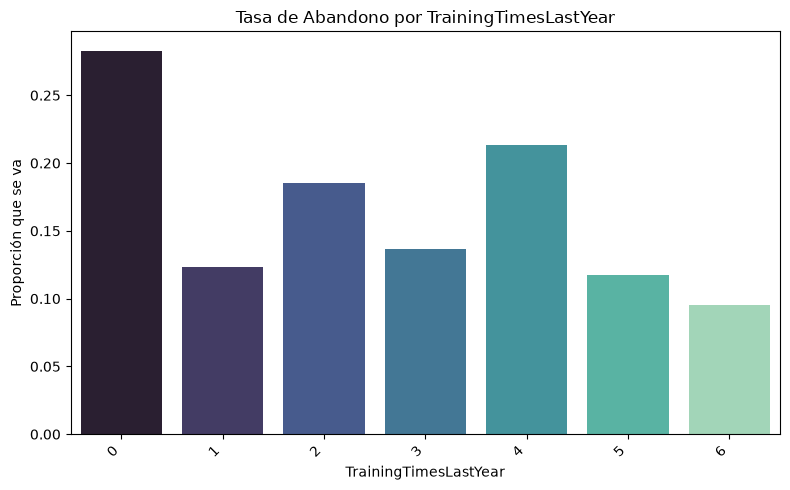

In [47]:
crear_graficos_barras(df_final, variables_numericas1)

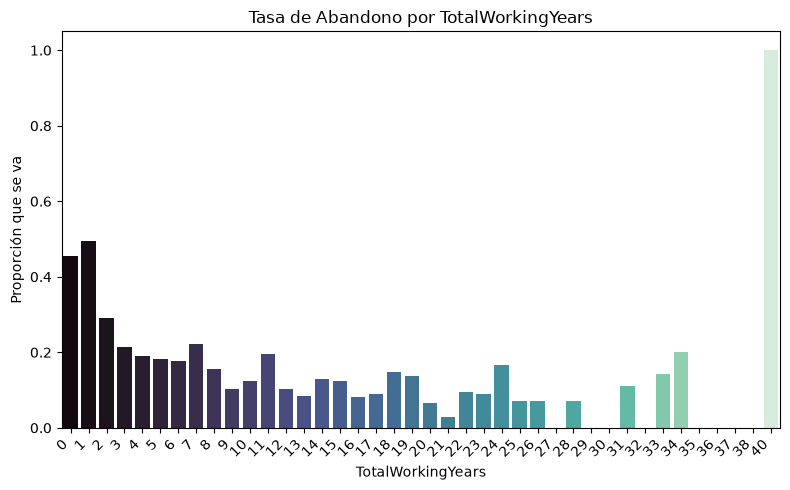

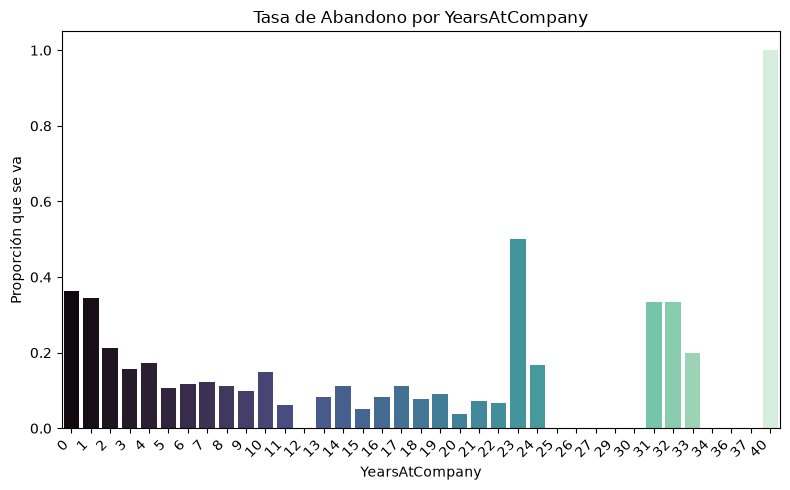

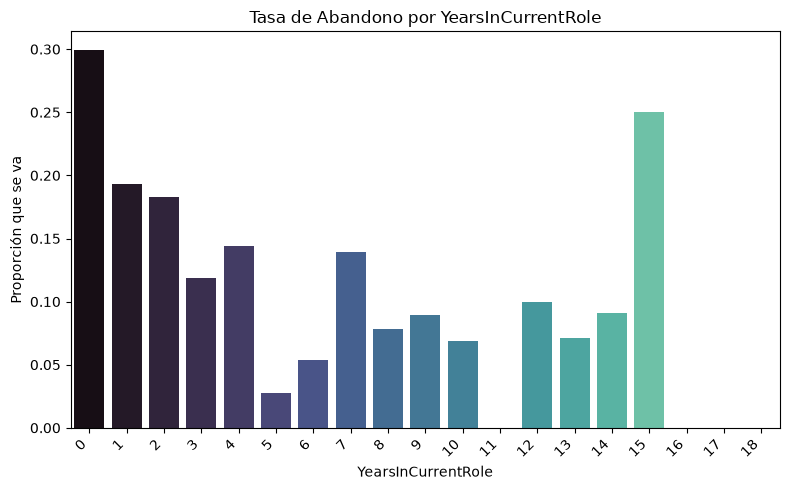

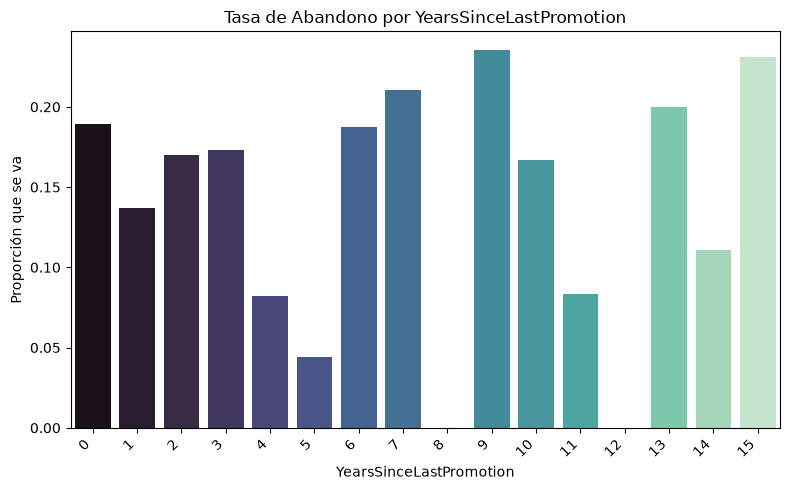

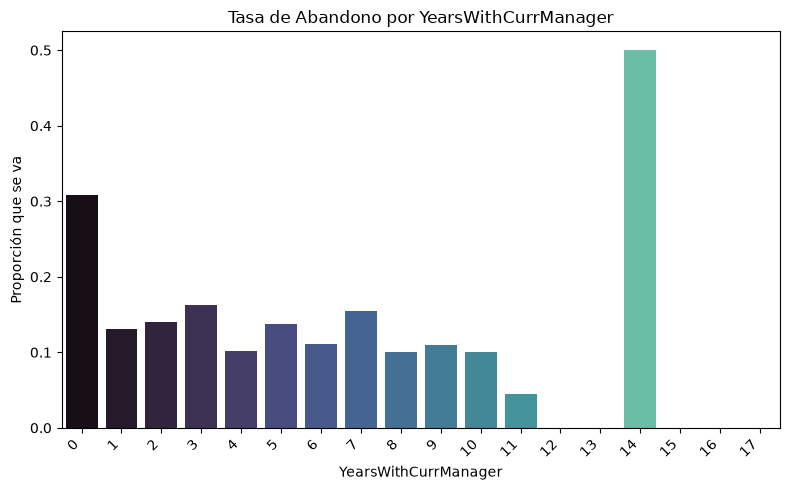

In [52]:
crear_graficos_barras(df_final, variables_tiempo)